# Supplementary Material S2 – *Phaseolus vulgaris*

## Proteome-wide analysis of sulfur-containing amino acids

This notebook documents a reproducible workflow for proteome-level amino acid composition analysis, with particular emphasis on sulfur-containing amino acids (S-AA), methionine (Met, M), and cysteine (Cys, C).

The workflow is implemented using the saa_proteome Python package and is applied here to the *Phaseolus vulgaris* reference proteome as part of the comparative study.

### Workflow overview

- FASTA parsing and sequence preprocessing  
- Amino acid composition analysis (Met%, Cys%, S-AA%)  
- Sliding-window methionine enrichment analysis  
- Ranking of sulfur-rich proteins  

To reproduce the results, run the notebook cells from top to bottom. Input files are referenced using paths relative to the project root directory. All required input files and paths are specified within the notebook.


## Software verification and environment check

The following code verifies the analytical environment by importing saa_proteome and reporting the package version used for all analyses

In [2]:
# Software verification and global parameters
# This cell defines all user-controlled inputs in one place to keep the workflow transparent and portable.

from pathlib import Path
import saa_proteome

# Report package version (useful for reproducibility)
print("saa_proteome version:", getattr(saa_proteome, "__version__", "unknown"))

saa_proteome version: 0.3.0


## Global analysis parameters and input definition

This section defines all user-controlled inputs and preprocessing options used throughout the notebook. These include the project root directory, input proteome FASTA file, species label, and global analysis parameters such as canonical amino-acid filtering (`CANONICAL_ONLY`), optional N-terminal methionine removal (`REMOVE_START_M`), and sliding-window settings for local methionine enrichment (`WINDOW_SIZE`, `WINDOW_STEP`). Centralizing these parameters ensures methodological transparency, consistent preprocessing across independent and downstream functions, and reproducible propagation of analysis settings throughout the workflow.

In [3]:
# Define the project root as the directory that contains this notebook.
# If you move the notebook, update PROJECT_ROOT accordingly.
PROJECT_ROOT = Path.cwd()

# Input proteome FASTA file (species-specific dataset used in this analysis)
FASTA_PATH = PROJECT_ROOT / "data" / "UP000000226_3885.fasta"
SPECIES_LABEL = "Phaseolus vulgaris"  # scientific species name used for labeling outputs and figures

print("FASTA_PATH:", FASTA_PATH)


FASTA_PATH: c:\Users\JCC\OneDrive\Desktop\Proteome_analysis_S_AA\data\UP000000226_3885.fasta


In [ ]:
# Analysis options
CANONICAL_ONLY = True    # retain only the 20 standard amino acids; remove non-canonical residues
REMOVE_START_M = True    # remove N-terminal Met only when the first residue is 'M'
WINDOW_SIZE = 100        # sliding-window length (aa) for local enrichment summaries
WINDOW_STEP = 1          # sliding-window step (aa)

## Input proteome data

The workflow is demonstrated using a publicly available proteome FASTA file corresponding to the predicted proteome of the selected crop species. Any proteome-scale FASTA file can be analyzed using the same steps, provided that the file contains standard one-letter amino acid sequences (protein FASTA). To apply the workflow to a different species, replace `FASTA_PATH` and `SPECIES_LABEL` in the parameter cell above.


In [5]:
# Validate the input FASTA file before analysis
from saa_proteome import validate_fasta

validation = validate_fasta(str(FASTA_PATH))

validation


,path,readable,looks_like_fasta,parseable,records_found_probe,first_protein_id,error_message
0,c:\Users\JCC\OneDrive\Desktop\Proteome_analysi...,True,True,True,1,tr|A0ACC3P112|A0ACC3P112_PHAVU,None


## Construction of the per-protein proteome metrics dataframe

The `load_proteome_metrics()` function converts the input proteome FASTA file into a per-protein metrics dataframe. For each protein sequence, the resulting table reports raw and cleaned sequence lengths, canonical residue filtering status, N-terminal methionine removal flags, the final adjusted length after optional N-terminal methionine removal, methionine and cysteine composition (percentage), combined sulfur amino-acid content (SAA = Met + Cys), and maximum local methionine enrichment calculated using a sliding-window approach (`WINDOW_SIZE`, `WINDOW_STEP`). The resulting dataframe (`df`) serves as the primary analytical backbone for all downstream quality control, ranking, composition, and summary analyses.

In [6]:
# Convert the proteome FASTA file to a per-protein metrics dataframe
# The resulting dataframe is the main input for downstream ranking, QC, and summary functions.

from saa_proteome import load_proteome_metrics 

df = load_proteome_metrics(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    window_size=WINDOW_SIZE,
    window_step=WINDOW_STEP
)

df


,species,protein_id,protein_id_raw,description,aa_count_raw,canonical_only,aa_count_cleaned,remove_start_m,start_m_removed,aa_count_adjusted,...,aa_M_freq,aa_N_freq,aa_P_freq,aa_Q_freq,aa_R_freq,aa_S_freq,aa_T_freq,aa_V_freq,aa_W_freq,aa_Y_freq
0,Phaseolus vulgaris,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,349,True,349,True,True,348,...,0.028736,0.063218,0.068966,0.025862,0.063218,0.043103,0.074713,0.068966,0.008621,0.028736
1,Phaseolus vulgaris,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,857,True,857,True,True,856,...,0.021028,0.046729,0.045561,0.031542,0.039720,0.086449,0.067757,0.059579,0.022196,0.044393
2,Phaseolus vulgaris,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,520,True,520,True,True,519,...,0.013487,0.025048,0.063584,0.034682,0.057803,0.069364,0.040462,0.096339,0.019268,0.030829
3,Phaseolus vulgaris,V7AF83,tr|V7AF83|V7AF83_PHAVU,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,412,True,412,True,True,411,...,0.024331,0.055961,0.051095,0.014599,0.051095,0.058394,0.043796,0.072993,0.009732,0.036496
4,Phaseolus vulgaris,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,421,True,421,True,True,420,...,0.016667,0.047619,0.071429,0.021429,0.088095,0.076190,0.057143,0.066667,0.016667,0.021429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28215,Phaseolus vulgaris,V7CGU2,tr|V7CGU2|V7CGU2_PHAVU,tr|V7CGU2|V7CGU2_PHAVU AMP-activated protein k...,516,True,516,True,True,515,...,0.019417,0.046602,0.038835,0.036893,0.050485,0.135922,0.044660,0.036893,0.025243,0.009709
28216,Phaseolus vulgaris,V7CJ07,tr|V7CJ07|V7CJ07_PHAVU,tr|V7CJ07|V7CJ07_PHAVU Uncharacterized protein...,693,True,693,True,True,692,...,0.018786,0.039017,0.024566,0.049133,0.047688,0.093931,0.021676,0.050578,0.013006,0.027457
28217,Phaseolus vulgaris,V7CJD9,tr|V7CJD9|V7CJD9_PHAVU,tr|V7CJD9|V7CJD9_PHAVU Arf-GAP domain-containi...,403,True,403,True,True,402,...,0.012438,0.064677,0.042289,0.029851,0.039801,0.154229,0.054726,0.032338,0.007463,0.012438
28218,Phaseolus vulgaris,V7CM20,tr|V7CM20|V7CM20_PHAVU,tr|V7CM20|V7CM20_PHAVU DUF241 domain protein O...,290,True,290,True,True,289,...,0.048443,0.058824,0.020761,0.041522,0.062284,0.121107,0.051903,0.058824,0.006920,0.010381


## Quality-control (QC) summary

The `qc_report()` generates a quality-control summary to confirm correct proteome parsing and preprocessing. The table reports basic properties of the processed proteome, including protein counts, adjusted sequence length statistics, and the frequency of N-terminal methionine removal. This output is used only for methodological validation.

In [7]:
# Quality-control (QC) summary

from saa_proteome import qc_report

qc = qc_report(df)

qc


,species,total_proteins,mean_length,median_length,min_length,max_length,removed_start_m_pct
0,Phaseolus vulgaris,28220,409.392736,343.0,7,5428,94.663359


## Proteome-level summary statistics

The saa_summary() function computes proteome-level summary statistics by aggregating per-protein sulfur amino-acid metrics into species-level descriptors. The function reports the total number of proteins analyzed and calculates mean, median, and selected quantiles (e.g., 50th, 90th, 99th percentiles) for methionine percentage, cysteine percentage, and total sulfur amino-acid content (SAA = Met + Cys). These statistics summarize the global distribution of sulfur-containing amino acids across the proteome.

In [8]:
# Proteome-level summary statistics

from saa_proteome import saa_summary

summary = saa_summary(df)

summary


,species,total_proteins,met_pct_mean,met_pct_median,met_pct_q50,met_pct_q90,met_pct_q99,cys_pct_mean,cys_pct_median,cys_pct_q50,cys_pct_q90,cys_pct_q99,saa_pct_mean,saa_pct_median,saa_pct_q50,saa_pct_q90,saa_pct_q99
0,Phaseolus vulgaris,28220,2.14204,2.033898,2.033898,3.553299,5.795652,2.07873,1.761129,1.761129,3.75,9.254885,4.22077,3.994845,3.994845,6.45933,11.904762


## Protein ranking based on quantitative composition metrics

Proteins were ranked using the `top_n_proteins()` function, which enables ordering of sequences according to any numeric metric derived from the adjusted protein sequence. The ranking metric can include global amino acid percentages (e.g., Met%, Cys%, S-AA%), sliding-window enrichment statistics (e.g., max_met_per_window), or other computed composition values.

The table below presents the top-ranked proteins based on the selected metric, along with sequence length and related composition parameters.

In [9]:
# Top-5 proteins ranked by maximum regional methionine enrichment
from saa_proteome import top_n_proteins

max_met_window = top_n_proteins(df,
               metric="max_met_per_window",
               n=5,
               value_scale='pct')
max_met_window

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,...,aa_M_pct,aa_N_pct,aa_P_pct,aa_Q_pct,aa_R_pct,aa_S_pct,aa_T_pct,aa_V_pct,aa_W_pct,aa_Y_pct
0,1,max_met_per_window,Phaseolus vulgaris,V7B0N7,tr|V7B0N7|V7B0N7_PHAVU ENTH domain-containing ...,995,3.316583,0.000000,3.316583,22.0,...,3.316583,5.929648,8.743719,7.537688,4.623116,13.065327,4.824121,3.919598,0.502513,3.718593
1,2,max_met_per_window,Phaseolus vulgaris,V7B8J7,tr|V7B8J7|V7B8J7_PHAVU BHLH domain-containing ...,477,6.918239,1.886792,8.805031,21.0,...,6.918239,6.289308,6.918239,5.450734,4.192872,12.578616,6.079665,5.660377,1.048218,1.467505
2,3,max_met_per_window,Phaseolus vulgaris,V7AN76,tr|V7AN76|V7AN76_PHAVU BHLH domain-containing ...,395,6.582278,2.784810,9.367089,20.0,...,6.582278,4.050633,6.835443,5.822785,4.810127,11.392405,6.075949,4.556962,0.759494,3.291139
3,4,max_met_per_window,Phaseolus vulgaris,V7CX26,tr|V7CX26|V7CX26_PHAVU BHLH domain-containing ...,496,6.451613,1.008065,7.459677,20.0,...,6.451613,5.846774,11.491935,6.451613,6.451613,9.072581,4.838710,5.241935,0.604839,1.612903
4,5,max_met_per_window,Phaseolus vulgaris,V7BN68,tr|V7BN68|V7BN68_PHAVU Uncharacterized protein...,110,18.181818,5.454545,23.636364,20.0,...,18.181818,0.000000,0.909091,0.000000,5.454545,13.636364,6.363636,15.454545,0.000000,0.000000


## Top-ranked proteins by sulfur amino acid content

The top_saa_proteins() identifies the top-ranked proteins enriched in sulfur-containing amino acids (methionine + cysteine), based on the precomputed S-AA percentage in the per-protein dataframe. Ranking inherits all preprocessing choices applied during dataframe construction, including N-terminal methionine removal.

In [10]:
# Identify proteins enriched in sulfur-containing amino acids (Met% + Cys%)

from saa_proteome import top_saa_proteins

top_saa = top_saa_proteins(df, n=10, value_scale='pct')

top_saa


,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,start_m_removed
0,1,saa_pct,Phaseolus vulgaris,V7CAD9,tr|V7CAD9|V7CAD9_PHAVU Cysteine-rich transmemb...,54,0.000000,25.925926,25.925926,0.000000,True
1,2,saa_pct,Phaseolus vulgaris,V7BED7,tr|V7BED7|V7BED7_PHAVU Uncharacterized protein...,8,0.000000,25.000000,25.000000,0.000000,False
2,3,saa_pct,Phaseolus vulgaris,V7C078,tr|V7C078|V7C078_PHAVU Cysteine-rich transmemb...,54,0.000000,24.074074,24.074074,0.000000,True
3,4,saa_pct,Phaseolus vulgaris,V7BN68,tr|V7BN68|V7BN68_PHAVU Uncharacterized protein...,110,18.181818,5.454545,23.636364,20.000000,True
4,5,saa_pct,Phaseolus vulgaris,V7AK77,tr|V7AK77|V7AK77_PHAVU Metallothionein-like pr...,78,5.128205,17.948718,23.076923,5.128205,True
5,6,saa_pct,Phaseolus vulgaris,V7CB39,tr|V7CB39|V7CB39_PHAVU G protein gamma domain-...,227,1.321586,21.585903,22.907489,3.000000,True
6,7,saa_pct,Phaseolus vulgaris,V7B633,tr|V7B633|V7B633_PHAVU Metallothionein-like pr...,78,3.846154,17.948718,21.794872,3.846154,True
7,8,saa_pct,Phaseolus vulgaris,V7B4F8,tr|V7B4F8|V7B4F8_PHAVU Uncharacterized protein...,83,1.204819,20.481928,21.686747,1.204819,True
8,9,saa_pct,Phaseolus vulgaris,V7B741,tr|V7B741|V7B741_PHAVU Uncharacterized protein...,24,8.333333,12.500000,20.833333,8.333333,True
9,10,saa_pct,Phaseolus vulgaris,V7BSW9,tr|V7BSW9|V7BSW9_PHAVU Uncharacterized protein...,109,7.339450,12.844037,20.183486,8.000000,True


## Proteome- and Protein-level amino acid composition

The `aa_composition_df()` function computes canonical amino-acid composition at either the proteome or individual protein level. For each sequence, the output reports residue counts, proportions (0–1), or percentages (0–100) for the 20 canonical amino acids, calculated from sequences processed according to the selected preprocessing parameters (e.g., canonical filtering and optional N-terminal methionine removal). When `extended=True`, the output additionally includes metadata describing preprocessing status and total adjusted residue counts.

In [11]:
# Amino acid composition of the species proteome
from saa_proteome import aa_composition_df

df_aa_proteome = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="proteome",          # Proteome-level aggregation
    value_scale="pct",       # {"count", "freq", "pct"}
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    extended=True              # Include metadata columns
)

df_aa_proteome

# Note: This function operates directly on the FASTA file rather than reusing the metrics dataframe. 
# This design ensures reproducibility from primary sequence data, avoids dependence on intermediate
# dataframe modifications, and allows the function to be used independently of upstream analysis steps.

,species,level,total_proteins,canonical_only,remove_start_m,proteins_dropped_empty,total_proteins_used,total_aa_adjusted,aa_value_scale,aa_A,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,Phaseolus vulgaris,proteome,28220,True,True,0,28220,11553063,pct,6.459906,...,2.170377,4.655536,4.856807,3.661168,5.12993,9.038642,4.993671,6.639581,1.292324,2.820023


In [12]:
# Amino acid composition at the individual protein level

df_aa_protein = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="protein",           # Per-protein composition
    value_scale="count",         # {"count", "freq", "pct"}
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    extended=True              # Include metadata columns
)

df_aa_protein.head()

,species,level,protein_id,protein_id_raw,description,canonical_only,aa_count_cleaned,remove_start_m,start_m_removed,aa_count_adjusted,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,Phaseolus vulgaris,protein,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,True,349,True,True,348,...,10.0,22.0,24.0,9.0,22.0,15.0,26.0,24.0,3.0,10.0
1,Phaseolus vulgaris,protein,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,True,857,True,True,856,...,18.0,40.0,39.0,27.0,34.0,74.0,58.0,51.0,19.0,38.0
2,Phaseolus vulgaris,protein,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,True,520,True,True,519,...,7.0,13.0,33.0,18.0,30.0,36.0,21.0,50.0,10.0,16.0
3,Phaseolus vulgaris,protein,V7AF83,tr|V7AF83|V7AF83_PHAVU,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,True,412,True,True,411,...,10.0,23.0,21.0,6.0,21.0,24.0,18.0,30.0,4.0,15.0
4,Phaseolus vulgaris,protein,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,True,421,True,True,420,...,7.0,20.0,30.0,9.0,37.0,32.0,24.0,28.0,7.0,9.0


In [13]:
# Example: Amino acid composition of a single protein

# Top SSA protein ID
protein_id = str(top_saa.loc[0, "protein_id"])

df_aa_single_protein = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="protein",
    value_scale="pct",
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    protein_id=protein_id,     # Select a specific protein
    extended=False             # Return only AA composition columns
)

df_aa_single_protein

,protein_id,aa_A,aa_C,aa_D,aa_E,aa_F,aa_G,aa_H,aa_I,aa_K,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,V7CAD9,5.555556,25.925926,3.703704,9.259259,3.703704,1.851852,3.703704,1.851852,1.851852,...,0.0,0.0,5.555556,3.703704,5.555556,1.851852,1.851852,5.555556,0.0,9.259259


## SAA composition for proteome or protein level

Sulfur amino-acid composition was quantified using `saa_composition_df()`, which derives methionine (Met), cysteine (Cys), and their combined value (SAA = Met + Cys) from canonical amino-acid profiles. Composition can be computed either at the proteome level (aggregated across all proteins) or at the individual protein level. Results may be expressed as absolute counts, proportions (0–1), or percentages (0–100).

In [14]:
# Compute aggregated sulfur amino-acid composition for the entire proteome.
from saa_proteome import saa_composition_df

saa_composition_df(FASTA_PATH, SPECIES_LABEL,
                   level='proteome',
                   value_scale='pct',
                   canonical_only=CANONICAL_ONLY, # Default is True
                   remove_start_m=REMOVE_START_M, # Default is True
                   )

,species,level,total_proteins,canonical_only,remove_start_m,proteins_dropped_empty,total_proteins_used,total_aa_adjusted,saa_value_scale,met,cys,saa
0,Phaseolus vulgaris,proteome,28220,True,True,0,28220,11553063,pct,2.170377,1.920521,4.090898


In [15]:
# Compute sulfur amino-acid composition at the individual protein level.
from saa_proteome import saa_composition_df

saa_composition_df(FASTA_PATH, SPECIES_LABEL,
                   level='protein',
                   value_scale='count',
                   canonical_only=CANONICAL_ONLY, # Default is True
                   remove_start_m=REMOVE_START_M, # Default is True
                   )

,species,protein_id,description,canonical_only,remove_start_m,start_m_removed,aa_count_cleaned,aa_count_adjusted,saa_value_scale,met,cys,saa
0,Phaseolus vulgaris,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,True,True,True,349,348,count,10.0,4.0,14.0
1,Phaseolus vulgaris,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,True,True,True,857,856,count,18.0,10.0,28.0
2,Phaseolus vulgaris,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,True,True,True,520,519,count,7.0,6.0,13.0
3,Phaseolus vulgaris,V7AF83,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,True,True,True,412,411,count,10.0,11.0,21.0
4,Phaseolus vulgaris,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,True,True,True,421,420,count,7.0,2.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...
28215,Phaseolus vulgaris,V7CGU2,tr|V7CGU2|V7CGU2_PHAVU AMP-activated protein k...,True,True,True,516,515,count,10.0,6.0,16.0
28216,Phaseolus vulgaris,V7CJ07,tr|V7CJ07|V7CJ07_PHAVU Uncharacterized protein...,True,True,True,693,692,count,13.0,13.0,26.0
28217,Phaseolus vulgaris,V7CJD9,tr|V7CJD9|V7CJD9_PHAVU Arf-GAP domain-containi...,True,True,True,403,402,count,5.0,7.0,12.0
28218,Phaseolus vulgaris,V7CM20,tr|V7CM20|V7CM20_PHAVU DUF241 domain protein O...,True,True,True,290,289,count,14.0,5.0,19.0


## Essential amino acid (EAA) summary

The `eaa_summary()` function computes essential amino acid (EAA) statistics at the protein level. For each protein sequence, the output reports the total EAA content (count, frequency, and percentage) and the relative contribution of each essential amino acid to the protein’s total EAA pool, based on the selected EAA profile.

In [16]:
# Essential amino acids (EAA) summary

from saa_proteome import eaa_summary

df_eaa = eaa_summary(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M
)

df_eaa

,species,protein_id,protein_id_raw,description,canonical_only,remove_start_m,eaa_count,eaa_freq,eaa_pct,aa_count_adjusted,...,eaa_profile,eaa_pct_F,eaa_pct_H,eaa_pct_I,eaa_pct_K,eaa_pct_L,eaa_pct_M,eaa_pct_T,eaa_pct_V,eaa_pct_W
0,Phaseolus vulgaris,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,True,True,158.0,0.454023,45.402299,348,...,human_classic,3.735632,2.586207,6.321839,5.747126,8.908046,2.873563,7.471264,6.896552,0.862069
1,Phaseolus vulgaris,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,True,True,397.0,0.463785,46.378505,856,...,human_classic,5.023364,3.621495,5.023364,5.957944,9.696262,2.102804,6.775701,5.957944,2.219626
2,Phaseolus vulgaris,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,True,True,218.0,0.420039,42.003854,519,...,human_classic,5.009634,1.734104,4.046243,4.046243,10.211946,1.348748,4.046243,9.633911,1.926782
3,Phaseolus vulgaris,V7AF83,tr|V7AF83|V7AF83_PHAVU,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,True,True,172.0,0.418491,41.849148,411,...,human_classic,2.919708,2.676399,6.326034,5.839416,9.002433,2.433090,4.379562,7.299270,0.973236
4,Phaseolus vulgaris,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,True,True,186.0,0.442857,44.285714,420,...,human_classic,5.000000,2.380952,3.095238,6.428571,11.666667,1.666667,5.714286,6.666667,1.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28215,Phaseolus vulgaris,V7CGU2,tr|V7CGU2|V7CGU2_PHAVU,tr|V7CGU2|V7CGU2_PHAVU AMP-activated protein k...,True,True,201.0,0.390291,39.029126,515,...,human_classic,3.300971,2.330097,5.825243,5.825243,9.126214,1.941748,4.466019,3.689320,2.524272
28216,Phaseolus vulgaris,V7CJ07,tr|V7CJ07|V7CJ07_PHAVU,tr|V7CJ07|V7CJ07_PHAVU Uncharacterized protein...,True,True,292.0,0.421965,42.196532,692,...,human_classic,2.890173,3.034682,5.635838,6.647399,13.583815,1.878613,2.167630,5.057803,1.300578
28217,Phaseolus vulgaris,V7CJD9,tr|V7CJD9|V7CJD9_PHAVU,tr|V7CJD9|V7CJD9_PHAVU Arf-GAP domain-containi...,True,True,155.0,0.385572,38.557214,402,...,human_classic,5.472637,1.741294,3.731343,9.701493,7.213930,1.243781,5.472637,3.233831,0.746269
28218,Phaseolus vulgaris,V7CM20,tr|V7CM20|V7CM20_PHAVU,tr|V7CM20|V7CM20_PHAVU DUF241 domain protein O...,True,True,129.0,0.446367,44.636678,289,...,human_classic,2.768166,1.384083,5.536332,6.574394,11.764706,4.844291,5.190311,5.882353,0.692042


## Converting to Publication-Ready Column Labels

The following example demonstrates how internal computational column names can be converted into human-readable labels using `apply_friendly_column_names()` without modifying any numerical results. The internal outputs use stable, machine-readable column names to ensure reproducibility and compatibility across analyses. For manuscript tables and reporting purposes, presentation-ready labels can be applied at the export stage. This conversion affects only column names and does not alter underlying values.

In [17]:
# Example output: Essential amino acids (EAA) summary
df_eaa.head() # previously computed

,species,protein_id,protein_id_raw,description,canonical_only,remove_start_m,eaa_count,eaa_freq,eaa_pct,aa_count_adjusted,...,eaa_profile,eaa_pct_F,eaa_pct_H,eaa_pct_I,eaa_pct_K,eaa_pct_L,eaa_pct_M,eaa_pct_T,eaa_pct_V,eaa_pct_W
0,Phaseolus vulgaris,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,True,True,158.0,0.454023,45.402299,348,...,human_classic,3.735632,2.586207,6.321839,5.747126,8.908046,2.873563,7.471264,6.896552,0.862069
1,Phaseolus vulgaris,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,True,True,397.0,0.463785,46.378505,856,...,human_classic,5.023364,3.621495,5.023364,5.957944,9.696262,2.102804,6.775701,5.957944,2.219626
2,Phaseolus vulgaris,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,True,True,218.0,0.420039,42.003854,519,...,human_classic,5.009634,1.734104,4.046243,4.046243,10.211946,1.348748,4.046243,9.633911,1.926782
3,Phaseolus vulgaris,V7AF83,tr|V7AF83|V7AF83_PHAVU,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,True,True,172.0,0.418491,41.849148,411,...,human_classic,2.919708,2.676399,6.326034,5.839416,9.002433,2.433090,4.379562,7.299270,0.973236
4,Phaseolus vulgaris,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,True,True,186.0,0.442857,44.285714,420,...,human_classic,5.000000,2.380952,3.095238,6.428571,11.666667,1.666667,5.714286,6.666667,1.666667


In [18]:
from saa_proteome import apply_friendly_column_names, eaa_summary

# Convert to publication-ready column names (presentation layer only)
df_eaa = apply_friendly_column_names(df_eaa)

df_eaa.head()

,Species,Protein ID,Protein ID (Raw FASTA Token),Protein Description,Canonical Amino Acids Only,Start-Met Removal Enabled,Essential Amino Acid Count,Essential Amino Acid Frequency,Essential Amino Acids (%),Sequence Length (Adjusted),...,Essential Amino Acid Profile,Phenylalanine (%),Histidine (%),Isoleucine (%),Lysine (%),Leucine (%),"Methionine (Essential, %)",Threonine (%),Valine (%),Tryptophan (%)
0,Phaseolus vulgaris,A0ACC3P112,tr|A0ACC3P112|A0ACC3P112_PHAVU,tr|A0ACC3P112|A0ACC3P112_PHAVU Uncharacterized...,True,True,158.0,0.454023,45.402299,348,...,human_classic,3.735632,2.586207,6.321839,5.747126,8.908046,2.873563,7.471264,6.896552,0.862069
1,Phaseolus vulgaris,A0ACC3P1A9,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU,tr|A0ACC3P1A9|A0ACC3P1A9_PHAVU Uncharacterized...,True,True,397.0,0.463785,46.378505,856,...,human_classic,5.023364,3.621495,5.023364,5.957944,9.696262,2.102804,6.775701,5.957944,2.219626
2,Phaseolus vulgaris,A0ACC3P1P0,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU,tr|A0ACC3P1P0|A0ACC3P1P0_PHAVU Uncharacterized...,True,True,218.0,0.420039,42.003854,519,...,human_classic,5.009634,1.734104,4.046243,4.046243,10.211946,1.348748,4.046243,9.633911,1.926782
3,Phaseolus vulgaris,V7AF83,tr|V7AF83|V7AF83_PHAVU,tr|V7AF83|V7AF83_PHAVU non-specific serine/thr...,True,True,172.0,0.418491,41.849148,411,...,human_classic,2.919708,2.676399,6.326034,5.839416,9.002433,2.433090,4.379562,7.299270,0.973236
4,Phaseolus vulgaris,V7AFD9,tr|V7AFD9|V7AFD9_PHAVU,tr|V7AFD9|V7AFD9_PHAVU non-specific serine/thr...,True,True,186.0,0.442857,44.285714,420,...,human_classic,5.000000,2.380952,3.095238,6.428571,11.666667,1.666667,5.714286,6.666667,1.666667


## Export the analysis results

The following example demonstrates how analysis results can be exported to a CSV file using `save_output()`. The code shows how a DataFrame produced by the workflow can be easily saved for external use or reporting.

In [19]:
from saa_proteome import apply_friendly_column_names, save_output

# Optional: Convert to publication-ready column names
df_eaa_pretty = apply_friendly_column_names(df_eaa)

# Export formatted table as a csv file
save_output(df_eaa_pretty, f"EAA_summary_{SPECIES_LABEL}")

Output file successfully saved to: EAA_summary_Phaseolus vulgaris.csv


## Amino acid frequency heatmap matrix

The `aa_heatmap_matrix() `function computes amino-acid frequency profiles for a selected set of proteins (here, the top SAA-enriched proteins). For each protein, the function recalculates the relative abundance (0–1) of the 20 canonical amino acids directly from the processed FASTA sequences, using the same preprocessing parameters (`CANONICAL_ONLY`, `REMOVE_START_M`). The resulting matrix is used for downstream heatmap visualization and comparative compositional analysis.

In [20]:
# Amino acid composition heatmap matrix

from saa_proteome import aa_heatmap_matrix

heatmap_df = aa_heatmap_matrix(
    df_top=top_saa,
    fasta_path=str(FASTA_PATH),
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M
)

heatmap_df

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
V7CAD9,0.055556,0.259259,0.037037,0.092593,0.037037,0.018519,0.037037,0.018519,0.018519,0.092593,0.000000,0.000000,0.055556,0.037037,0.055556,0.018519,0.018519,0.055556,0.000000,0.092593
V7BED7,0.125000,0.250000,0.000000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,0.000000,0.000000,0.125000,0.000000,0.000000,0.000000,0.125000,0.125000,0.000000,0.000000
V7C078,0.055556,0.240741,0.018519,0.074074,0.018519,0.037037,0.037037,0.018519,0.037037,0.055556,0.000000,0.000000,0.074074,0.074074,0.037037,0.074074,0.074074,0.000000,0.000000,0.074074
V7BN68,0.036364,0.054545,0.018182,0.009091,0.009091,0.036364,0.072727,0.045455,0.036364,0.081818,0.181818,0.000000,0.009091,0.000000,0.054545,0.136364,0.063636,0.154545,0.000000,0.000000
V7AK77,0.051282,0.179487,0.025641,0.076923,0.000000,0.179487,0.000000,0.000000,0.076923,0.038462,0.051282,0.051282,0.051282,0.000000,0.000000,0.076923,0.076923,0.038462,0.000000,0.025641
V7CB39,0.022026,0.215859,0.017621,0.048458,0.026432,0.035242,0.004405,0.013216,0.070485,0.088106,0.013216,0.022026,0.118943,0.004405,0.052863,0.127753,0.052863,0.022026,0.022026,0.022026
V7B633,0.038462,0.179487,0.025641,0.064103,0.012821,0.205128,0.000000,0.000000,0.064103,0.025641,0.038462,0.051282,0.038462,0.038462,0.000000,0.064103,0.076923,0.051282,0.000000,0.025641
V7B4F8,0.096386,0.204819,0.048193,0.012048,0.012048,0.192771,0.024096,0.000000,0.012048,0.000000,0.012048,0.024096,0.036145,0.000000,0.072289,0.120482,0.096386,0.036145,0.000000,0.000000
V7B741,0.083333,0.125000,0.000000,0.000000,0.041667,0.125000,0.041667,0.125000,0.041667,0.166667,0.083333,0.000000,0.000000,0.041667,0.000000,0.000000,0.000000,0.125000,0.000000,0.000000
V7BSW9,0.036697,0.128440,0.045872,0.009174,0.000000,0.018349,0.018349,0.055046,0.091743,0.064220,0.073394,0.055046,0.064220,0.045872,0.036697,0.091743,0.045872,0.091743,0.009174,0.018349


## Visualization of AA composition heatmap

The following code provides an illustrative example of visualizing amino acid composition of the top-ten highest percent of sulfur-containing amino acids protein sequences using `plot_aa_heatmap` function. The plot is generated from the amino acid frequency matrix computed earlier and is included solely for exploratory and presentation purposes.

<Axes: xlabel='Amino Acid', ylabel='Protein ID'>

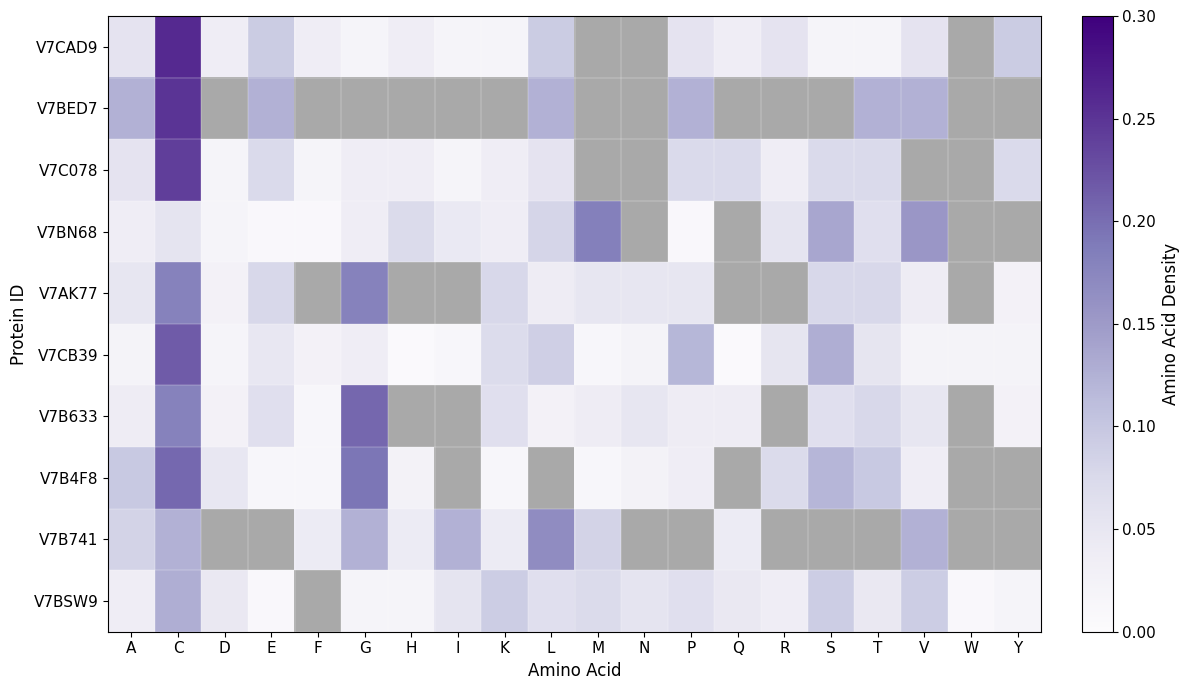

In [21]:
#  Amino acid density heatmap (Default output)
from saa_proteome import plot_aa_heatmap

plot_aa_heatmap(heatmap_df)

# Light shades represent low frequency values approaching zero, while gray boxes indicate complete absence (frequency = 0).

<Axes: title={'center': 'Amino Acid Density Heatmap: Phaseolus vulgaris'}, xlabel='Amino Acid', ylabel='Protein ID'>

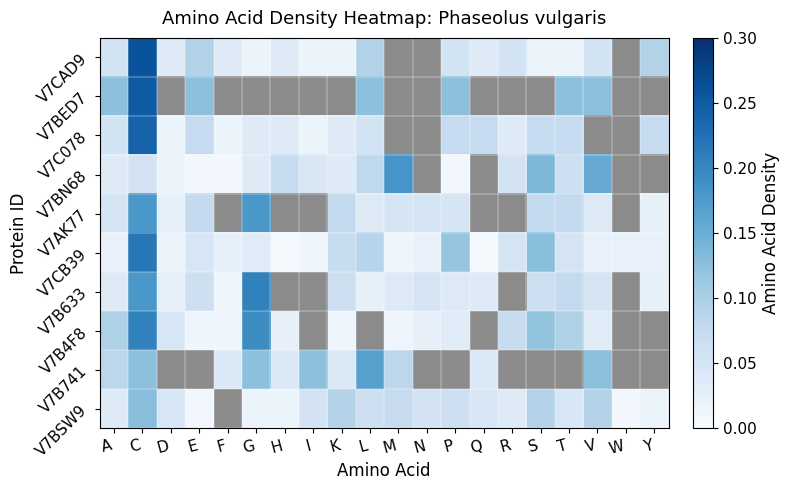

In [22]:
#  Customized Amino acid density heatmap (Fully Parameterized Example)
from saa_proteome import plot_aa_heatmap

# Optional: define absent mask explicitly. 
# This identifies which cells should be treated as “absent” and painted with the overlay color (e.g., dark gray).
absent_mask = heatmap_df.eq(0) # Here, absent means frequency == 0 (default)

plot_aa_heatmap(
    heatmap_df,
    
    # --- Title & axis labels ---
    title=f"Amino Acid Density Heatmap: {SPECIES_LABEL}",
    xlabel="Amino Acid",
    ylabel="Protein ID",

    # --- Figure control ---
    figsize=(8, 5),
    font_scale=1,
    # --- Colormap control ---
    cmap="Blues",   # Any valid Matplotlib colormap (e.g., "viridis", "Purples", "Oranges", "magma", "OrRd")
    vmin=0,
    vmax=0.30,        # Fixed scaling for cross-species comparability
    # --- Absent AA overlay ---
    absent_mask=absent_mask,
    absent_color= "#8B8B8B",   # Light gray for absent residues
    # --- Grid styling ---
    linewidths=0.3,
    linecolor="White",
    # --- Colorbar ---
    cbar=True,
    cbar_label="Amino Acid Density",
    # --- Tick rotation ---
    xtick_rotation=15,
    ytick_rotation=45,
    xtick_ha="right",
    ytick_ha="right",
    # --- Save plot ---
    save_plot=True,
    save_filename=f"AA_heatmap_{SPECIES_LABEL}" # by default, it saves to the current working directory
)

# Light shades represent low frequency values approaching zero, while gray boxes indicate complete absence (frequency = 0).

## Plotting Barchart for Amino Acid Frequency

### Example 1: Bar plot of top SAA-ranked proteins

In [23]:
# Preview: Top-10 proteins ranked by total sulfur amino acid percentage (SAA = Met% + Cys%)
top_saa.head() # Previously computed

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,start_m_removed
0,1,saa_pct,Phaseolus vulgaris,V7CAD9,tr|V7CAD9|V7CAD9_PHAVU Cysteine-rich transmemb...,54,0.000000,25.925926,25.925926,0.000000,True
1,2,saa_pct,Phaseolus vulgaris,V7BED7,tr|V7BED7|V7BED7_PHAVU Uncharacterized protein...,8,0.000000,25.000000,25.000000,0.000000,False
2,3,saa_pct,Phaseolus vulgaris,V7C078,tr|V7C078|V7C078_PHAVU Cysteine-rich transmemb...,54,0.000000,24.074074,24.074074,0.000000,True
3,4,saa_pct,Phaseolus vulgaris,V7BN68,tr|V7BN68|V7BN68_PHAVU Uncharacterized protein...,110,18.181818,5.454545,23.636364,20.000000,True
4,5,saa_pct,Phaseolus vulgaris,V7AK77,tr|V7AK77|V7AK77_PHAVU Metallothionein-like pr...,78,5.128205,17.948718,23.076923,5.128205,True


<Axes: title={'center': 'Top 10 SAA-Enriched Proteins - Phaseolus vulgaris'}, xlabel='Protein ID', ylabel='S-AA (%)'>

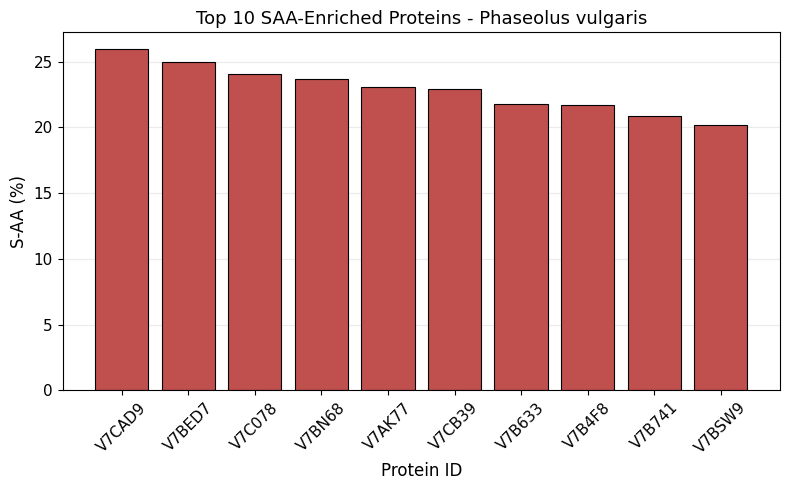

In [24]:
# Bar plot for top S-AA prtoeins
from saa_proteome import plot_bar

plot_bar(
    df=top_saa,
    x="protein_id",
    y="saa_pct",
    title=f"Top 10 SAA-Enriched Proteins - {SPECIES_LABEL}",
    ylabel="S-AA (%)",
    xlabel="Protein ID",
    xtick_rotation=45,
)

### Example 2: Bar plot for the amino acid composition of the richest-SAA protein

In [25]:
from saa_proteome import aa_profile_table, plot_bar

# Convert wide AA composition (single row) to long format using aa_profile_table function
df_single_long = aa_profile_table(df_aa_single_protein) # Top SSA protein

df_single_long.head()

,AA,Percentage
0,A,5.555556
1,C,25.925926
2,D,3.703704
3,E,9.259259
4,F,3.703704


<Axes: title={'center': 'Amino Acid Composition - V7CAD9'}, xlabel='Amino Acid', ylabel='Percentage (%)'>

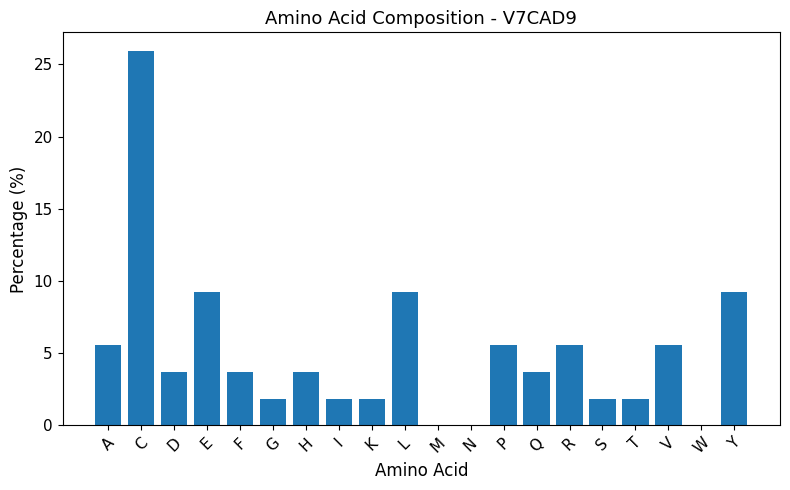

In [26]:
# Plot the AA composition of the highest-SAA protein with some customization
plot_bar(
    df=df_single_long,
    x="AA",
    y="Percentage",
    title=f"Amino Acid Composition - {protein_id}",
    xlabel="Amino Acid",
    ylabel="Percentage (%)",
    xtick_rotation=45,
    grid=False,
    font_scale=1,
    color= 'tab:blue', # Color can also be a single string (e.g., "Red", "tab:orange", '#0f0f0f80') or a list of colors ['red', 'blue', 'orange',...]
    edgecolor= 'None', # Turn Edge color off
)

### Example 3: Bar plot - Window-based methionine enrichment (Top-5 proteins)

This example illustrates visualization of proteins ranked by maximum regional methionine enrichment (`max_met_per_window`). The bar chart displays the top five proteins previously identified using the `top_n_proteins()` function with `metric="max_met_per_window"`.

In [27]:
# DataFrame previously computed. It contains the top-5 proteins ranked by maximum methionine percentage 
# observed within a 100-aa sliding window.

max_met_window

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,...,aa_M_pct,aa_N_pct,aa_P_pct,aa_Q_pct,aa_R_pct,aa_S_pct,aa_T_pct,aa_V_pct,aa_W_pct,aa_Y_pct
0,1,max_met_per_window,Phaseolus vulgaris,V7B0N7,tr|V7B0N7|V7B0N7_PHAVU ENTH domain-containing ...,995,3.316583,0.000000,3.316583,22.0,...,3.316583,5.929648,8.743719,7.537688,4.623116,13.065327,4.824121,3.919598,0.502513,3.718593
1,2,max_met_per_window,Phaseolus vulgaris,V7B8J7,tr|V7B8J7|V7B8J7_PHAVU BHLH domain-containing ...,477,6.918239,1.886792,8.805031,21.0,...,6.918239,6.289308,6.918239,5.450734,4.192872,12.578616,6.079665,5.660377,1.048218,1.467505
2,3,max_met_per_window,Phaseolus vulgaris,V7AN76,tr|V7AN76|V7AN76_PHAVU BHLH domain-containing ...,395,6.582278,2.784810,9.367089,20.0,...,6.582278,4.050633,6.835443,5.822785,4.810127,11.392405,6.075949,4.556962,0.759494,3.291139
3,4,max_met_per_window,Phaseolus vulgaris,V7CX26,tr|V7CX26|V7CX26_PHAVU BHLH domain-containing ...,496,6.451613,1.008065,7.459677,20.0,...,6.451613,5.846774,11.491935,6.451613,6.451613,9.072581,4.838710,5.241935,0.604839,1.612903
4,5,max_met_per_window,Phaseolus vulgaris,V7BN68,tr|V7BN68|V7BN68_PHAVU Uncharacterized protein...,110,18.181818,5.454545,23.636364,20.0,...,18.181818,0.000000,0.909091,0.000000,5.454545,13.636364,6.363636,15.454545,0.000000,0.000000


<Axes: title={'center': 'Top-5 proteins ranked by maximum regional methionine enrichment'}, xlabel='Protein ID', ylabel='Max Met per 100 AA (%)'>

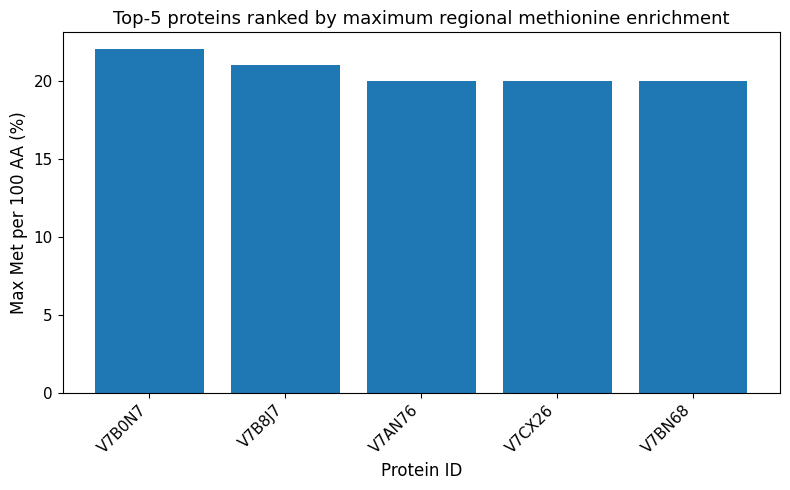

In [28]:
#  Bar plot of top-5 proteins ranked by maximum regional methionine enrichment

from saa_proteome.viz import plot_bar

plot_bar(
    max_met_window,
    x="protein_id",
    y="max_met_per_window",
    title="Top-5 proteins ranked by maximum regional methionine enrichment",
    xlabel="Protein ID",
    ylabel="Max Met per 100 AA (%)",
    font_scale=1.0,
    xtick_rotation=45,
    xtick_ha="right",
    grid=False,
    grid_axis="y",
    color= 'tab:blue', # Color can also be a single string (e.g., "Red", "tab:orange", '#0f0f0f80') or a list of colors ['red', 'blue', 'orange',...]
    edgecolor= 'None', # Turn Edge color off
)

## Data Dictionary (Output Column Definitions)

To enhance transparency and reproducibility, the following table provides a mapping between internal computational column names and their corresponding publication-ready labels. Internal names are used throughout the analytical workflow to ensure consistency and stability of the computational API. Human-readable labels are applied only at the presentation and export stage.

The table below is generated programmatically from the package mapping to ensure that documentation remains synchronized with the codebase.

In [29]:
from saa_proteome import preview_data_dictionary

output_dictionary = preview_data_dictionary()

output_dictionary

,column,label
0,A,Alanine
1,C,Cysteine
2,D,Aspartic Acid
3,E,Glutamic Acid
4,F,Phenylalanine
...,...,...
178,total_proteins,Total Proteins
179,total_proteins_used,Total Proteins Used
180,value_scale,Value Scale
181,window_size,Sliding Window Size (Amino Acids)


In [30]:
# Example: Output label definitions for particular output dataframe
preview_data_dictionary(heatmap_df)

,column,label
0,A,Alanine
1,C,Cysteine
2,D,Aspartic Acid
3,E,Glutamic Acid
4,F,Phenylalanine
5,G,Glycine
6,H,Histidine
7,I,Isoleucine
8,K,Lysine
9,L,Leucine


## Reproducibility statement

All analyses in this notebook are reproducible using the `saa_proteome` package and the input FASTA file specified in the parameter cell. For transparent provenance, record the repository tag/commit hash used for the analysis in the manuscript or supplement.

## Code availability

Repository (GitHub): https://github.com/Hussam-Omari/saa-proteome  
Release tag used in this supplement: v0.3.0
